### **Imports**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

### **Connexion MySQL**

In [2]:
import yaml

with open("../config/db_config.yaml", "r") as f:
    config = yaml.safe_load(f)

conn = mysql.connector.connect(
    host=config["host"],
    user=config["user"],
    password=config["password"],
    database=config["database"]
)

### **Fonction utilitaire pour exécuter une requête SQL**

In [3]:
def query(sql):
    """
    Exécute une requête SQL et retourne le résultat sous forme de DataFrame Pandas.

    Paramètres
    ----------
    sql : str
        Requête SQL à exécuter sur la connexion MySQL active.

    Retour
    ------
    pandas.DataFrame
        Résultat de la requête SQL, avec les colonnes et lignes retournées par MySQL.

    Notes
    -----
    Cette fonction sert de raccourci pour simplifier l'exécution des requêtes
    dans le notebook. Elle utilise la connexion globale `conn` et garantit
    un retour directement exploitable pour les visualisations.
    """
    return pd.read_sql(sql, conn)

### **Visualisation KPI par KPI (dans l’ordre exact du fichier SQL)**

#### **KPI 1 — Nombre de matchs par édition**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)
/tmp/ipykernel_92405/3216177155.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df1, x="edition", y="nb_matches", palette="Blues_d")


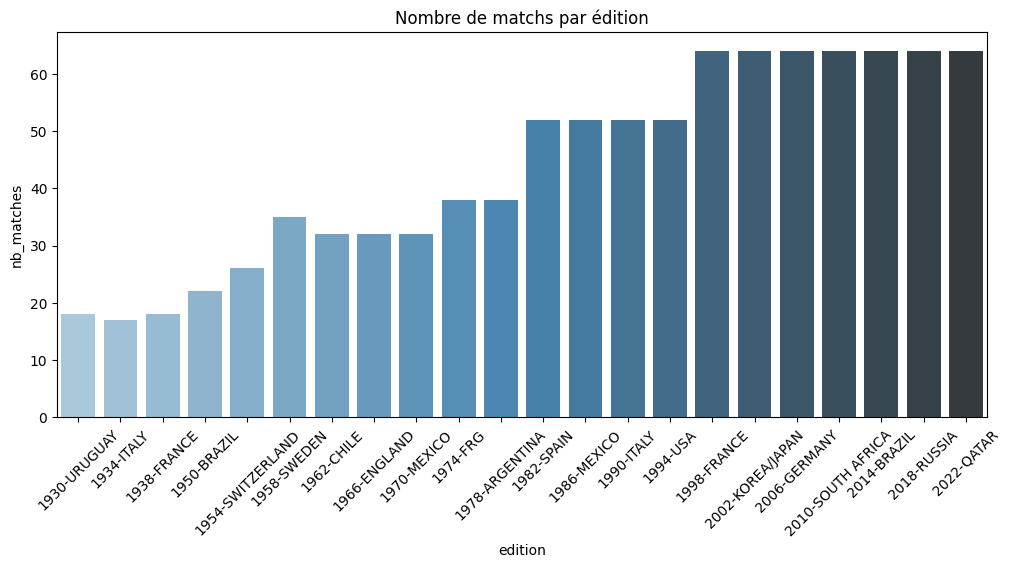

In [4]:
sql = """
SELECT edition, COUNT(*) AS nb_matches
FROM match_final
GROUP BY edition
ORDER BY edition;
"""
df1 = query(sql)

plt.figure(figsize=(12,5))
sns.barplot(data=df1, x="edition", y="nb_matches", palette="Blues_d")
plt.title("Nombre de matchs par édition")
plt.xticks(rotation=45)
plt.show()

#### **KPI 2 — Nombre total de buts par édition**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


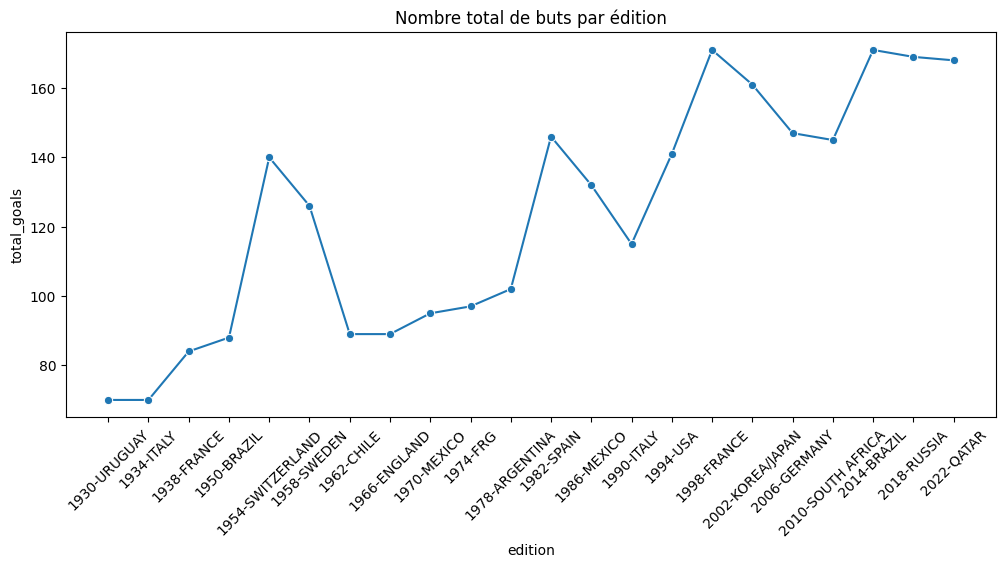

In [5]:
sql = """
SELECT edition, SUM(home_result + away_result) AS total_goals
FROM match_final
GROUP BY edition
ORDER BY edition;
"""
df2 = query(sql)

plt.figure(figsize=(12,5))
sns.lineplot(data=df2, x="edition", y="total_goals", marker="o")
plt.title("Nombre total de buts par édition")
plt.xticks(rotation=45)
plt.show()

#### **KPI 3 - Moyenne de buts par match par édition**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


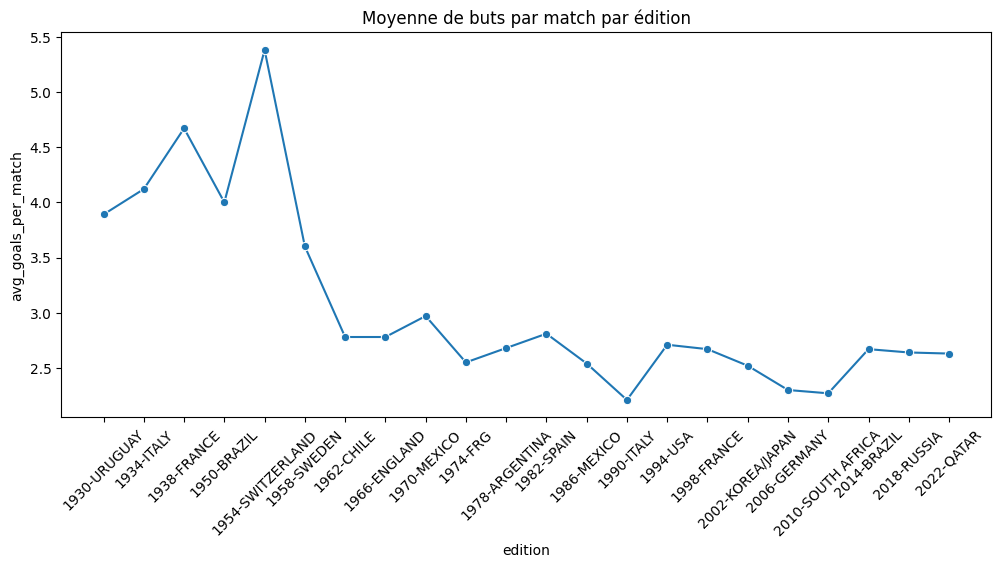

In [6]:
sql = """
SELECT edition, ROUND(AVG(home_result + away_result), 2) AS avg_goals_per_match
FROM match_final
GROUP BY edition
ORDER BY edition;
"""
df3 = query(sql)

plt.figure(figsize=(12,5))
sns.lineplot(data=df3, x="edition", y="avg_goals_per_match", marker="o")
plt.title("Moyenne de buts par match par édition")
plt.xticks(rotation=45)
plt.show()

#### **KPI 4 - Répartition des résultats**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


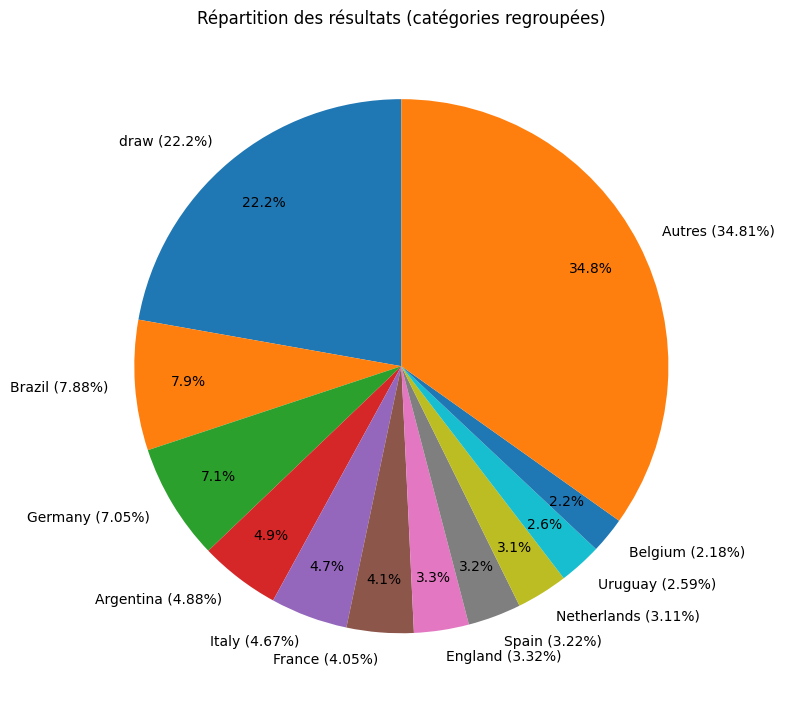

In [7]:
sql = """
SELECT 
    result,
    COUNT(*) AS nb_matches,
    ROUND(100 * COUNT(*) / (SELECT COUNT(*) FROM match_final), 2) AS pct
FROM match_final
GROUP BY result
ORDER BY pct DESC;
"""
df4 = query(sql)

# Seuil de regroupement (en %)
threshold = 2.0

# Séparer les catégories principales et les petites
main_df = df4[df4["pct"] >= threshold].copy()
other_df = df4[df4["pct"] < threshold].copy()

# Ajouter la catégorie "Autres" si nécessaire
if not other_df.empty:
    autres_pct = other_df["pct"].sum()
    autres_nb = other_df["nb_matches"].sum()
    main_df.loc[len(main_df)] = ["Autres", autres_nb, autres_pct]

# Tracer le pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    main_df["pct"],
    labels=[f"{row['result']} ({row['pct']}%)" for _, row in main_df.iterrows()],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)
plt.title("Répartition des résultats (catégories regroupées)")
plt.tight_layout()
plt.show()

#### **KPI 5 — Équipe la plus victorieuse**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)
/tmp/ipykernel_92405/3174577747.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df5, x="wins", y="winning_team", palette="Greens_d")


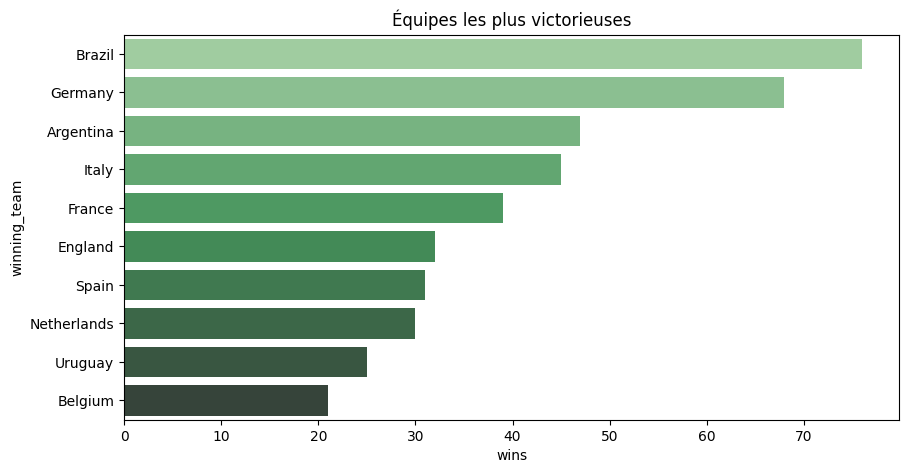

In [8]:
sql = """
SELECT result AS winning_team, COUNT(*) AS wins
FROM match_final
WHERE result <> 'draw'
GROUP BY winning_team
ORDER BY wins DESC
LIMIT 10;
"""
df5 = query(sql)

plt.figure(figsize=(10,5))
sns.barplot(data=df5, x="wins", y="winning_team", palette="Greens_d")
plt.title("Équipes les plus victorieuses")
plt.show()

#### **KPI 6 — Matchs par ville**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)
/tmp/ipykernel_92405/1886385582.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df6.head(20), x="nb_matches", y="city", palette="Purples_d")


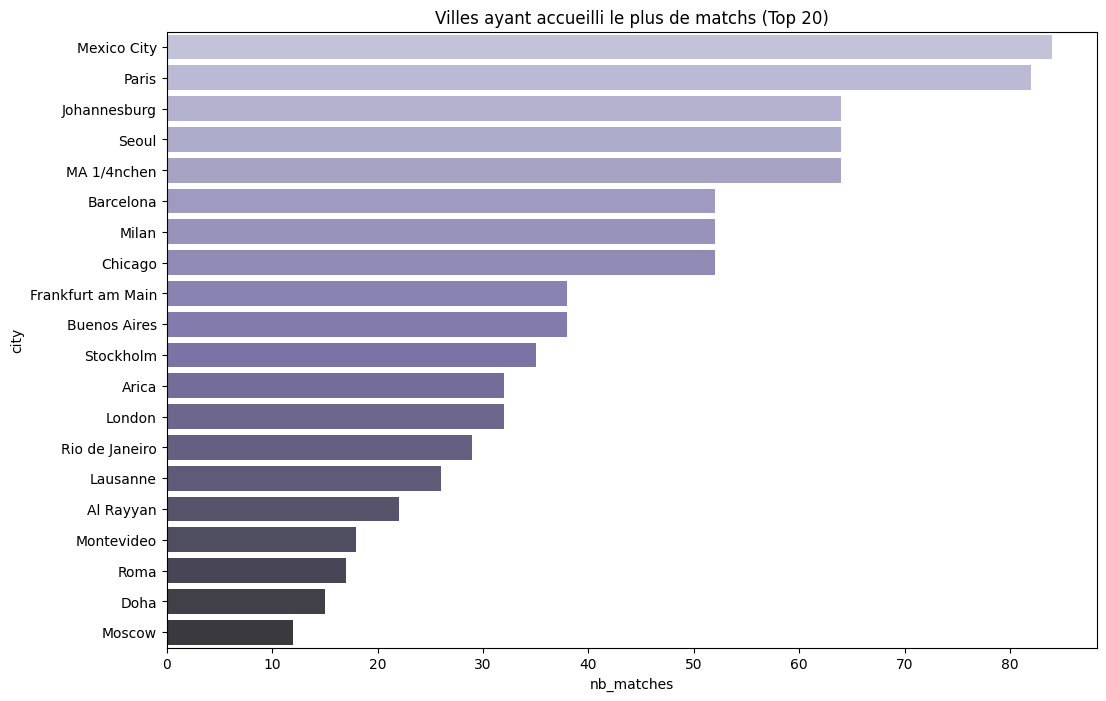

In [9]:
sql = """
SELECT city, COUNT(*) AS nb_matches
FROM match_final
GROUP BY city
ORDER BY nb_matches DESC;
"""
df6 = query(sql)

plt.figure(figsize=(12,8))
sns.barplot(data=df6.head(20), x="nb_matches", y="city", palette="Purples_d")
plt.title("Villes ayant accueilli le plus de matchs (Top 20)")
plt.show()

#### **KPI 7 — Matchs par stade**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)
/tmp/ipykernel_92405/1844890406.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df7, x="nb_matches", y="stadium_name", palette="Oranges_d")


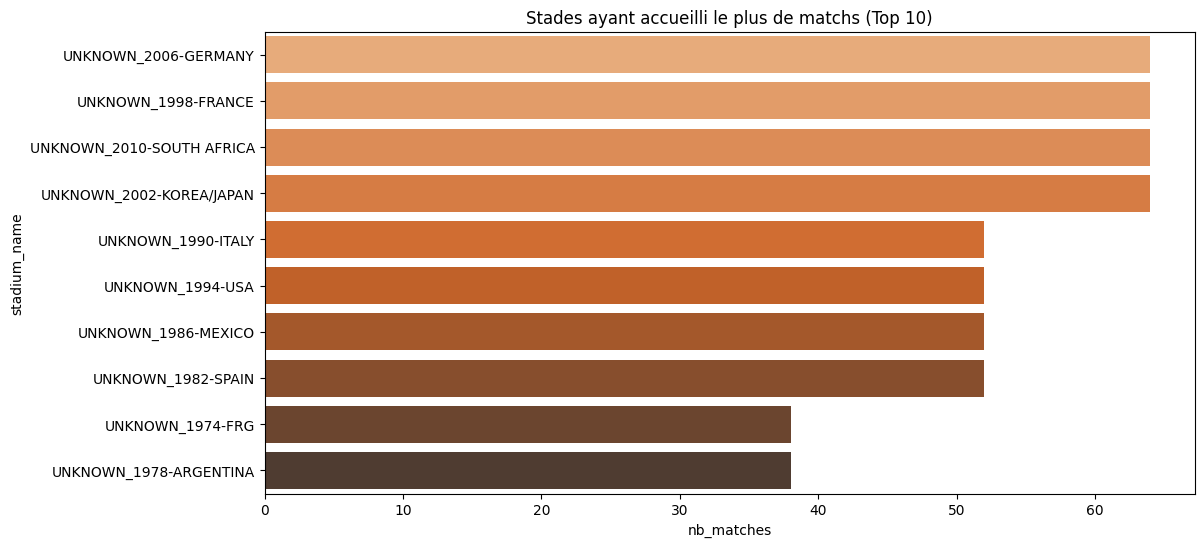

In [10]:
sql = """
SELECT s.stadium_name, c.city_name, COUNT(*) AS nb_matches
FROM `match` m
JOIN stadium s ON m.id_stadium = s.id_stadium
LEFT JOIN city c ON s.id_city = c.id_city
GROUP BY s.stadium_name, c.city_name
ORDER BY nb_matches DESC
LIMIT 10;
"""
df7 = query(sql)

plt.figure(figsize=(12,6))
sns.barplot(data=df7, x="nb_matches", y="stadium_name", palette="Oranges_d")
plt.title("Stades ayant accueilli le plus de matchs (Top 10)")
plt.show()

#### **KPI 8 — Score le plus fréquent**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)
/tmp/ipykernel_92405/1814945078.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df8, x="occurrences", y="score", palette="Reds_d")


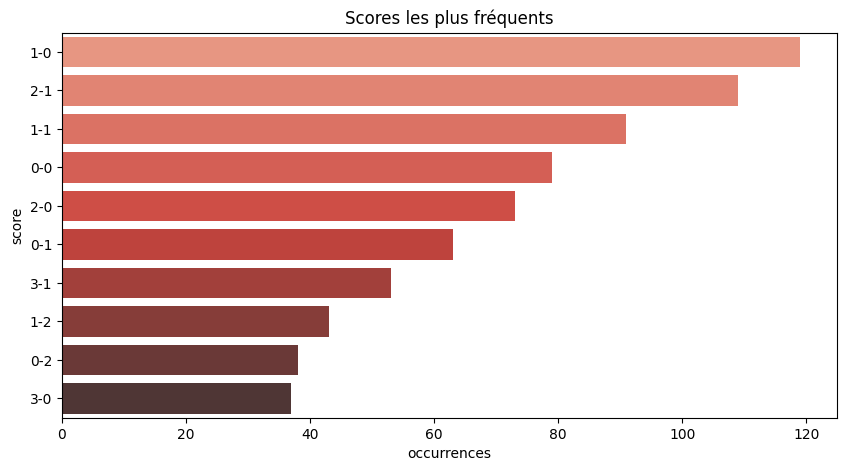

In [11]:
sql = """
SELECT CONCAT(home_result, '-', away_result) AS score,
       COUNT(*) AS occurrences
FROM match_final
GROUP BY score
ORDER BY occurrences DESC
LIMIT 10;
"""
df8 = query(sql)

plt.figure(figsize=(10,5))
sns.barplot(data=df8, x="occurrences", y="score", palette="Reds_d")
plt.title("Scores les plus fréquents")
plt.show()

#### **KPI 9 — Matchs les plus prolifiques**

In [12]:
sql = """
SELECT home_team, away_team, edition, date,
       home_result, away_result,
       (home_result + away_result) AS total_goals
FROM match_final
ORDER BY total_goals DESC
LIMIT 10;
"""
df9 = query(sql)
df9

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,home_team,away_team,edition,date,home_result,away_result,total_goals
0,Austria,Switzerland,1954-SWITZERLAND,1954-01-01,7,5,12
1,Brazil,Poland,1938-FRANCE,1938-01-01,6,5,11
2,Hungary,Germany,1954-SWITZERLAND,1954-01-01,8,3,11
3,Hungary,El Salvador,1982-SPAIN,1982-01-01,10,1,11
4,France,Paraguay,1958-SWEDEN,1958-01-01,7,3,10
5,Argentina,Mexico,1930-URUGUAY,1930-01-01,6,3,9
6,Hungary,South Korea,1954-SWITZERLAND,1954-01-01,9,0,9
7,Germany,Turkey,1954-SWITZERLAND,1954-01-01,7,2,9
8,France,Germany,1958-SWEDEN,1958-01-01,6,3,9
9,Serbia,Zaire,1974-FRG,1974-01-01,9,0,9


#### **KPI 10 — Matchs par tour**

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)
/tmp/ipykernel_92405/1026651542.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df10, x="nb_matches", y="round", palette="coolwarm")


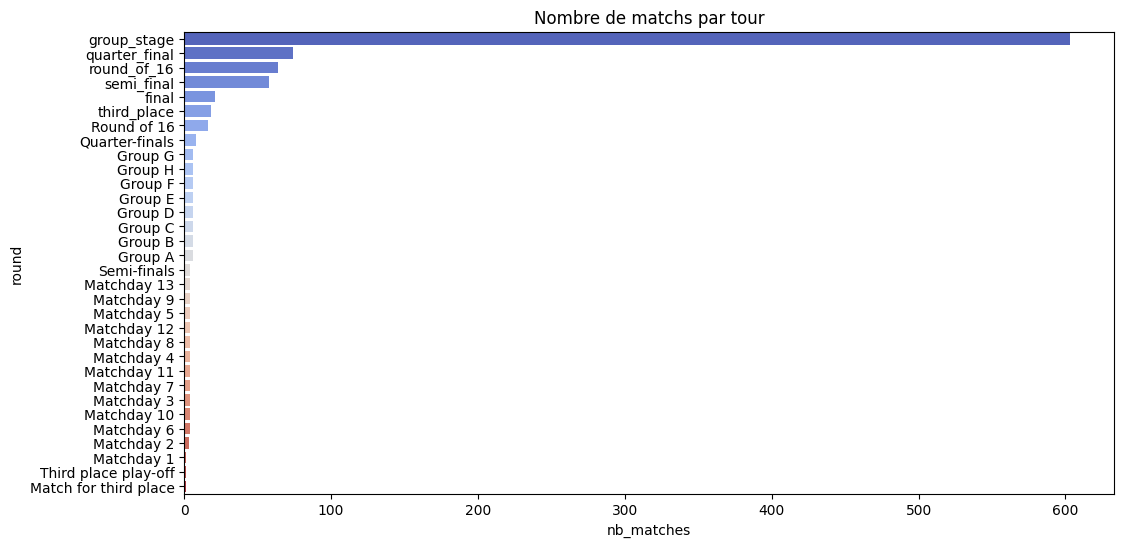

In [13]:
sql = """
SELECT round, COUNT(*) AS nb_matches
FROM match_final
GROUP BY round
ORDER BY nb_matches DESC;
"""
df10 = query(sql)

plt.figure(figsize=(12,6))
sns.barplot(data=df10, x="nb_matches", y="round", palette="coolwarm")
plt.title("Nombre de matchs par tour")
plt.show()

In [14]:
query("""
SELECT edition, city, COUNT(*) AS nb_matches
FROM match_final
WHERE city = 'Montevideo'
GROUP BY edition
ORDER BY edition;
""")

/tmp/ipykernel_92405/1004016459.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,edition,city,nb_matches
0,1930-URUGUAY,Montevideo,18
